# DeepCRISPR Scientific Discovery Demo
### 从已有实验结果展示：多模型预测 → 模型归因 → 因素发现

**这是一个"只读结果"的演示 Notebook**：不训练模型、不重跑实验、不需要 GPU。

| 项目 | 内容 |
| :--- | :--- |
| 目标系统 | CRISPR-Cas9（SpCas9，NGG PAM；本数据集 PAM 位于第 21–23 位） |
| 数据集 | DeepCRISPR 公开数据：4 个细胞系（HCT116 / HEK293T / HeLa / HL60） |
| 输入信息 | 23 nt 靶序列（A/C/G/T one-hot）+ 4 条表观遗传轨道（CTCF / DNase / H3K4me3 / RRBS） |
| 模型 | Linear Regression、XGBoost、MLP、Dual-Branch CNN（序列卷积核 3/5/7）、Transformer |
| 解释方法 | 回归系数、TreeSHAP、Integrated Gradients（IG）、In Silico Mutagenesis（ISM）、注意力 |
| 平台定位 | 不仅做**预测**，而是把预测、归因、统计与跨细胞系设计组织成**影响因素发现流程** |

本 Notebook 用 4 张图回答 4 个问题：模型是否学到信号 → 模型在看序列的哪里 → 序列上下文尺度是否有影响 → 细胞环境是否提供额外预测信息。

> 所有数字都来自 `results/` 中已有的结果文件；缺少文件时对应小节会打印 `SKIP` 警告并跳过，不做任何伪造。


## Part 2 — Dataset & Experimental Design

只读取 `results/` 中的实验索引表，汇总本次受控实验的设计规模（不重新计算任何科学量）。


In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) 定位项目根目录与结果目录（相对路径，不硬编码任何绝对路径） ---
def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "results").is_dir():
            return p
    return start

PROJECT_ROOT = find_project_root(Path.cwd())
RESULTS_DIR = PROJECT_ROOT / "results"

# 选择包含 analyse_out 的结果批次（优先 batch_20260909_full）
def find_batch(results_dir: Path) -> Path | None:
    preferred = results_dir / "batch_20260909_full"
    if (preferred / "analyse_out" / "tables").is_dir():
        return preferred
    for d in sorted(results_dir.iterdir()):
        if d.is_dir() and (d / "analyse_out" / "tables").is_dir():
            return d
    return None

BATCH_DIR = find_batch(RESULTS_DIR)
TABLES = (BATCH_DIR / "analyse_out" / "tables") if BATCH_DIR else None
print("PROJECT_ROOT :", PROJECT_ROOT)
print("BATCH_DIR    :", BATCH_DIR)
print("TABLES       :", TABLES)


def load_table(name: str, **kwargs) -> pd.DataFrame | None:
    """读取 results/ 下的既有结果表；文件不存在时返回 None 并给出明确警告。"""
    if TABLES is None:
        print(f"[SKIP] no result batch found under {RESULTS_DIR}")
        return None
    path = TABLES / name
    if not path.exists():
        print(f"[SKIP] missing result file: {path.relative_to(PROJECT_ROOT)}")
        return None
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return pd.read_csv(path, **kwargs)


PROJECT_ROOT : /home/zhang/bioprogram/Submit
BATCH_DIR    : /home/zhang/bioprogram/Submit/results/batch_20260909_full
TABLES       : /home/zhang/bioprogram/Submit/results/batch_20260909_full/analyse_out/tables


In [2]:
# --- 2) 实验设计索引表 ---
experiments = load_table("experiment_table.csv")

if experiments is None:
    design = pd.DataFrame()
else:
    experiments["is_cnn"] = experiments["model"].str.startswith("cnn")
    design = pd.DataFrame([
        {"item": "cell lines", "value": ", ".join(sorted(set(experiments.cell_line.unique()) - {"none"}))
                                          + "  (mixed-split rows use cell_line='none')"},
        {"item": "environment factors", "value": "CTCF, DNase, H3K4me3, RRBS (4)"},
        {"item": "environment combinations", "value": f"{experiments.environment.nunique()} (2^4 factorial design)"},
        {"item": "model configurations", "value": f"{experiments.model.nunique()} "
                                                 f"({', '.join(sorted(experiments.model.unique()))})"},
        {"item": "split strategies", "value": "single (0.70/0.15/0.15), all (held-out cell line), "
                                              "mixed (4 cell lines, seeds 42-45)"},
        {"item": "random seeds", "value": ", ".join(str(s) for s in sorted(experiments.random_seed.unique()))},
        {"item": "total trained runs (reused, not re-run)", "value": f"{len(experiments)}"},
    ])
    display(design)                                        # noqa: F821 (notebook builtin)


,item,value
0,cell lines,"hct116, hek293t, hela, hl60 (mixed-split rows..."
1,environment factors,"CTCF, DNase, H3K4me3, RRBS (4)"
2,environment combinations,16 (2^4 factorial design)
3,model configurations,"7 (cnn(3|3), cnn(5|3), cnn(7|3), linear, mlp, ..."
4,split strategies,"single (0.70/0.15/0.15), all (held-out cell li..."
5,random seeds,"42, 43, 44, 45"
6,"total trained runs (reused, not re-run)",1344


**读法**：`single` 为单细胞系内划分（每细胞系 1 个种子），`mixed` 为四细胞系混合的 4 个种子，
`all` 为按 held-out 细胞系分组的行。因此每个模型配置都有 16 环境组合 × 多个划分/种子，
总计 **1 344 次已完成的训练运行**——本 Notebook 全部复用这些结果。

> 数据限制（如实说明）：本批次的 `all` 划分与 `single` 划分的 R² 逐位相同，
> 因此本 Notebook **不**把 `all` 结果当作跨细胞系泛化证据。


## Part 3 — Prediction Performance

**问题**：平台中的模型是否学到了编辑效率（editing efficiency）信号？

只展示汇总统计（中位数与四分位距），不打印 1 344 行明细。Linear Regression 在部分运行中数值发散
（|R²| > 10），平台的处理方式是**标记并隔离**，而不是删除，因此下表同时给出发散计数。


In [3]:
if experiments is None:
    print("[SKIP] Part 3 requires experiment_table.csv")
    perf = None
else:
    DIVERGED = 10.0                                   # 与平台配置一致：|R²|>10 视为数值发散
    exp = experiments.copy()
    exp["diverged"] = exp["R2"].abs() >= DIVERGED
    stable = exp[~exp["diverged"]]

    perf = (stable.groupby(["model", "split_type"])
            .agg(n=("R2", "size"), R2_median=("R2", "median"),
                 R2_q1=("R2", lambda s: s.quantile(0.25)),
                 R2_q3=("R2", lambda s: s.quantile(0.75)),
                 RMSE_median=("RMSE", "median"), MAE_median=("MAE", "median"),
                 Spearman_median=("Spearman", "median"))
            .reset_index())
    div = exp.groupby(["model", "split_type"])["diverged"].sum().rename("diverged_runs").reset_index()
    perf = perf.merge(div, on=["model", "split_type"], how="left")
    display(perf.round(3))                            # noqa: F821


,model,split_type,n,R2_median,R2_q1,R2_q3,RMSE_median,MAE_median,Spearman_median,diverged_runs
0,cnn(3|3),all,64,0.035,0.022,0.063,0.145,0.118,0.221,0
1,cnn(3|3),mixed,64,0.060,0.052,0.066,0.161,0.126,0.241,0
2,cnn(3|3),single,64,0.035,0.022,0.063,0.145,0.118,0.221,0
3,cnn(5|3),all,64,0.057,0.044,0.088,0.143,0.114,0.284,0
4,cnn(5|3),mixed,64,0.135,0.124,0.143,0.154,0.117,0.351,0
5,cnn(5|3),single,64,0.057,0.044,0.088,0.143,0.114,0.284,0
6,cnn(7|3),all,64,0.080,0.063,0.101,0.142,0.115,0.303,0
7,cnn(7|3),mixed,64,0.148,0.131,0.156,0.154,0.116,0.378,0
8,cnn(7|3),single,64,0.080,0.063,0.101,0.142,0.115,0.303,0
9,linear,all,43,0.087,-0.001,0.101,0.124,0.103,0.304,21


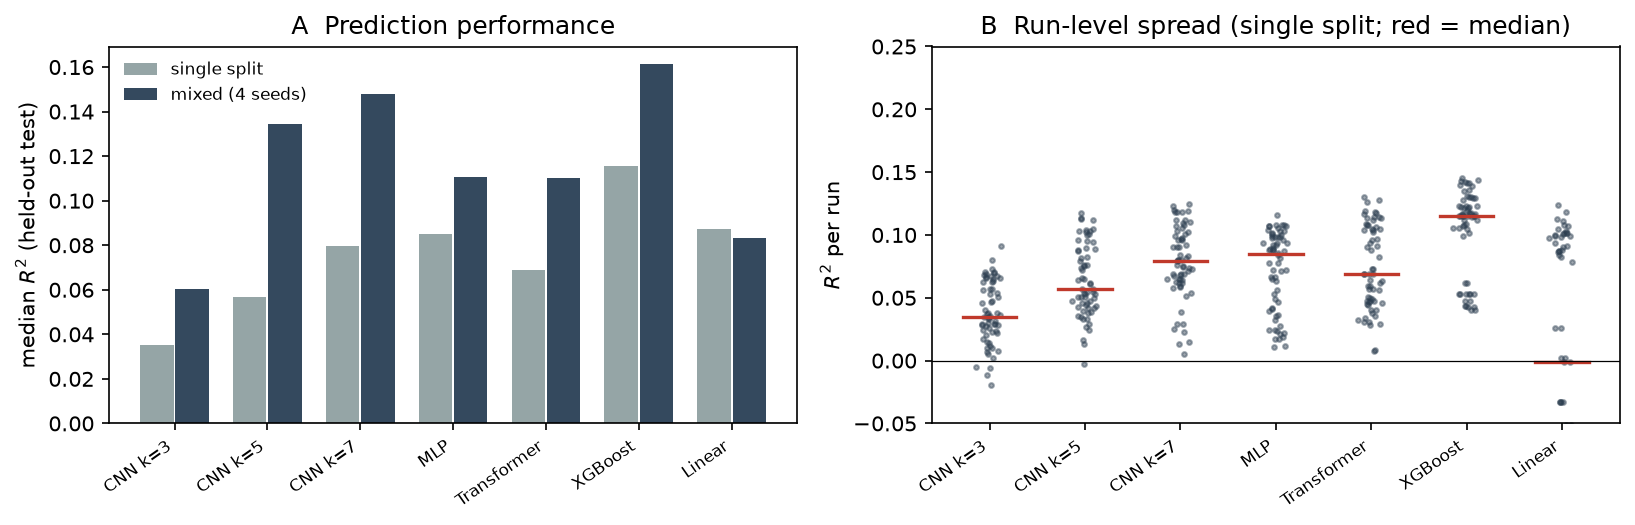

In [4]:
# --- Figure 1: model performance overview ---
if experiments is not None and not perf.empty:
    order = ["cnn(3|3)", "cnn(5|3)", "cnn(7|3)", "mlp", "transformer", "xgboost", "linear"]
    labels = {"cnn(3|3)": "CNN k=3", "cnn(5|3)": "CNN k=5", "cnn(7|3)": "CNN k=7",
              "mlp": "MLP", "transformer": "Transformer", "xgboost": "XGBoost",
              "linear": "Linear"}
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), dpi=150)

    ax = axes[0]
    for i, split in enumerate(["single", "mixed"]):
        vals = [perf[(perf.model == m) & (perf.split_type == split)]["R2_median"].squeeze()
                if len(perf[(perf.model == m) & (perf.split_type == split)]) else np.nan
                for m in order]
        ax.bar(np.arange(len(order)) + (i - 0.5) * 0.38, vals, width=0.36,
               label={"single": "single split", "mixed": "mixed (4 seeds)"}[split],
               color=["#95a5a6", "#34495e"][i])
    ax.axhline(0, color="k", lw=0.6)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([labels[m] for m in order], rotation=35, ha="right", fontsize=8)
    ax.set_ylabel(r"median $R^2$ (held-out test)")
    ax.set_title("A  Prediction performance")
    ax.legend(fontsize=8, frameon=False)

    ax = axes[1]
    single = exp[(exp.split_type == "single")]
    for i, m in enumerate(order):
        sub = single[single.model == m]
        jitter = np.random.default_rng(0).normal(0, 0.06, len(sub))
        ax.scatter(np.full(len(sub), i) + jitter, sub["R2"], s=5, alpha=0.45, color="#2c3e50")
        ax.plot([i - 0.28, i + 0.28], [sub["R2"].median()] * 2, color="#c0392b", lw=1.6)
    ax.axhline(0, color="k", lw=0.6)
    ax.set_ylim(-0.05, 0.25)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([labels[m] for m in order], rotation=35, ha="right", fontsize=8)
    ax.set_ylabel(r"$R^2$ per run")
    ax.set_title("B  Run-level spread (single split; red = median)")
    fig.tight_layout()

    FIG_DIR = PROJECT_ROOT / "notebooks" / "figures"
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIG_DIR / "fig1_model_performance.png", bbox_inches="tight")
    plt.show()
else:
    print("[SKIP] Figure 1 skipped (no experiment index)")


**观察**：所有模型都取得正的中位 R²，说明序列 + 表观遗传输入中包含可学习的编辑效率信号；
但绝对水平有限（中位 R² 约 0.03–0.16），说明本案例的可预测信号较弱。
**解释边界**：预测性能用于确认平台可以进入解释与因素发现阶段，**不能**据此推断某个模型"发现了更重要的生物学因素"。


## Part 4 — Scientific Discovery

### 4.1 Sequence attribution：模型在看序列的哪里？

读取已有的 attribution 汇总表（`attribution_summary.csv`），对五类模型的**主归因方法**按位置求平均，
并在每个模型内部归一化（消除模型间量纲差异）。区间定义为：PAM（21–23）、PAM 邻近种子区（17–20）、
种子核心区（9–16）、PAM 远端区（1–8）。

> **重要**：这是 model-derived attribution evidence（模型依赖强度），**不是**因果证明，也不是统计显著性。


In [5]:
PRIMARY_METHOD = {"linear": "linear_coefficient", "xgboost": "xgboost_treeshap", "mlp": "mlp_ig",
                  "cnn": "cnn_ig", "transformer": "transformer_attention"}
MODEL_LABEL = {"linear": "Linear", "xgboost": "XGBoost", "mlp": "MLP",
               "cnn": "CNN", "transformer": "Transformer"}

attribution = load_table("attribution_summary.csv", low_memory=False,
                         usecols=["channel", "position", "model", "split_type", "cell_line",
                                  "environment", "method", "importance"])

profile = None
if attribution is None:
    print("[SKIP] 4.1 requires attribution_summary.csv")
else:
    att = attribution[
        attribution.channel.isin(list("ACGT"))
        & attribution.method.isin(PRIMARY_METHOD.values())
        & (attribution.split_type == "single")
        & attribution.environment.isin(["sequence", "all"])
    ].copy()
    att["abs_importance"] = pd.to_numeric(att["importance"], errors="coerce").abs()
    # 先在每个 (model, method, cell_line, environment) 上下文内归一化, 再跨上下文取平均:
    # 与平台论文/分析产物的口径一致, 且不会被个别发散运行主导。
    context_key = ["model", "method", "cell_line", "environment"]
    per_ctx = (att.groupby(context_key + ["position"])["abs_importance"].mean().reset_index())
    per_ctx["share"] = (per_ctx.groupby(context_key)["abs_importance"]
                        .transform(lambda s: s / s.sum()))
    profile = (per_ctx.pivot_table(index="position", columns="model", values="share")
               .reindex(columns=["linear", "xgboost", "mlp", "cnn", "transformer"]).dropna(how="all"))
    display(profile.round(4))                         # noqa: F821

    # 每个位置的跨模型支持度 + position 18 的 C 通道占比
    top3 = {m: set(profile[m].nlargest(3).index) for m in profile.columns}
    position_summary = pd.DataFrame({
        "position": profile.index,
        "mean_normalized_importance": profile.mean(axis=1).values,
        "model_top3_support": [int(sum(p in top3[m] for m in profile.columns)) for p in profile.index],
    }).set_index("position")

    c18 = att[(att.position == 18)]
    c_share = (c18[c18.channel == "C"].groupby("model")["abs_importance"].sum()
               / c18.groupby("model")["abs_importance"].sum()).rename("C_share_at_position_18")
    display(pd.concat([position_summary.tail(8).round(5), c_share.round(3)], axis=1))  # noqa: F821


model,linear,xgboost,mlp,cnn,transformer
position,,,,,
1,0.0000,0.0648,0.0525,0.0436,0.1027
2,0.0000,0.0466,0.0386,0.0382,0.0603
3,0.0000,0.0296,0.0299,0.0435,0.0384
4,0.0000,0.0369,0.0387,0.0428,0.0281
5,0.0000,0.0234,0.0284,0.0408,0.0259
6,0.0000,0.0383,0.0299,0.0446,0.0279
7,0.0000,0.0244,0.0267,0.0430,0.0277
8,0.0000,0.0203,0.0522,0.0427,0.0296
9,0.0000,0.0394,0.0332,0.0440,0.0351


,mean_normalized_importance,model_top3_support,C_share_at_position_18
16,0.03796,0.0,NaN
17,0.05519,0.0,NaN
18,0.08481,3.0,NaN
19,0.08008,4.0,NaN
20,0.08168,4.0,NaN
21,0.04035,0.0,NaN
22,0.07185,1.0,NaN
23,0.08154,2.0,NaN
cnn,NaN,NaN,0.294
linear,NaN,NaN,0.333


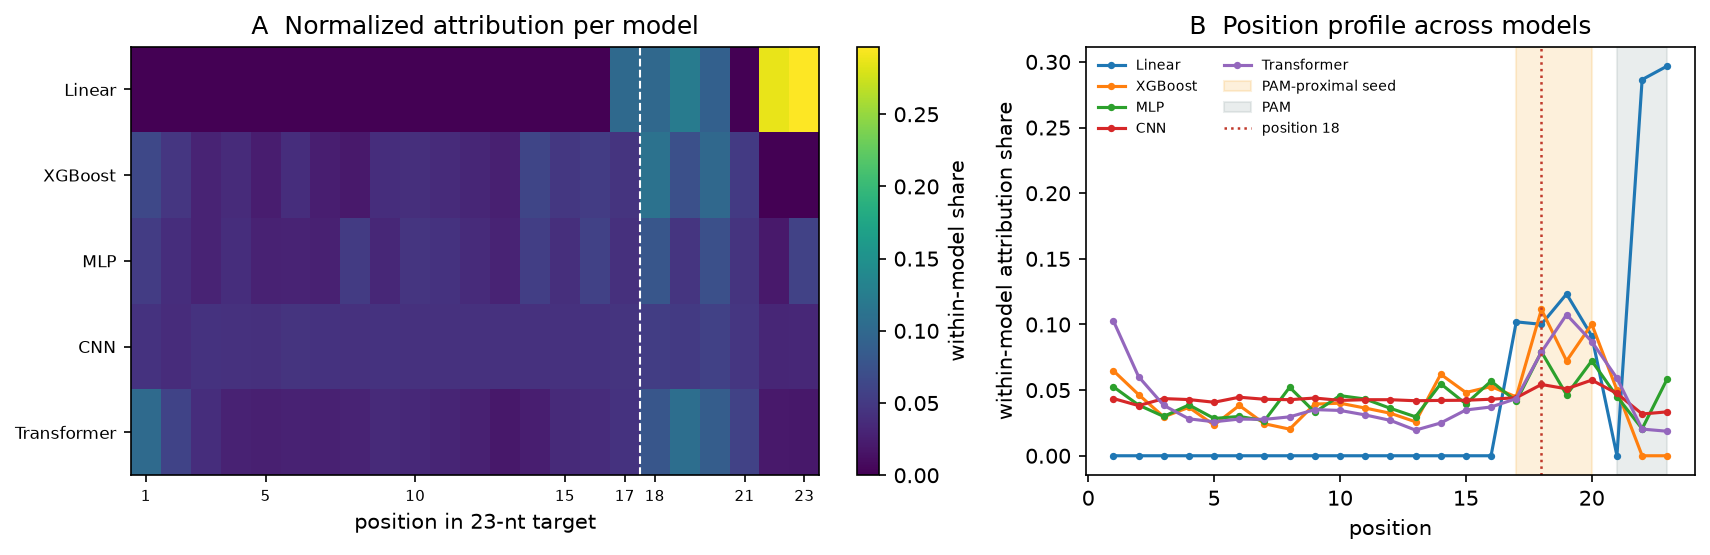

,PAM (21-23),PAM-proximal seed (17-20),Seed core (9-16),PAM-distal (1-8)
model,,,,
linear,0.1945,0.1041,0.0000,0.0000
xgboost,0.0167,0.0822,0.0421,0.0355
mlp,0.0415,0.0598,0.0424,0.0371
cnn,0.0376,0.0518,0.0426,0.0424
transformer,0.0327,0.0792,0.0305,0.0426


Region with the highest mean attribution per model:
PAM (21-23)                       linear
PAM-proximal seed (17-20)         linear
Seed core (9-16)                     cnn
PAM-distal (1-8)             transformer


In [6]:
# --- Figure 2: cross-model sequence attribution ---
if profile is not None and not profile.empty:
    regions = {"PAM (21-23)": (21, 23), "PAM-proximal seed (17-20)": (17, 20),
               "Seed core (9-16)": (9, 16), "PAM-distal (1-8)": (1, 8)}
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8), dpi=150,
                             gridspec_kw={"width_ratios": [1.25, 1]})

    ax = axes[0]
    mat = profile.T.values                                  # models x positions
    im = ax.imshow(mat, aspect="auto", cmap="viridis")
    ax.set_yticks(range(len(profile.columns)))
    ax.set_yticklabels([MODEL_LABEL[m] for m in profile.columns], fontsize=8)
    ax.set_xticks([0, 4, 9, 14, 16, 17, 20, 22])
    ax.set_xticklabels([1, 5, 10, 15, 17, 18, 21, 23], fontsize=7)
    ax.axvline(16.5, color="white", ls="--", lw=1.0)
    ax.set_xlabel("position in 23-nt target")
    ax.set_title("A  Normalized attribution per model")
    fig.colorbar(im, ax=ax, fraction=0.046, label="within-model share")

    ax = axes[1]
    for m in profile.columns:
        ax.plot(profile.index, profile[m], marker="o", ms=2.5, label=MODEL_LABEL[m])
    ax.axvspan(17, 20, color="#f39c12", alpha=0.15, label="PAM-proximal seed")
    ax.axvspan(21, 23, color="#95a5a6", alpha=0.2, label="PAM")
    ax.axvline(18, color="#c0392b", lw=1.2, ls=":", label="position 18")
    ax.set_xlabel("position")
    ax.set_ylabel("within-model attribution share")
    ax.set_title("B  Position profile across models")
    ax.legend(fontsize=6.5, frameon=False, ncol=2)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "fig2_sequence_attribution.png", bbox_inches="tight")
    plt.show()

    region_means = pd.DataFrame({name: profile.loc[lo:hi].mean() for name, (lo, hi) in regions.items()})
    display(region_means.round(4))                          # noqa: F821
    print("Region with the highest mean attribution per model:")
    print(region_means.idxmax().to_string())


**观察**：四个模型类（CNN / MLP / Transformer / XGBoost）都把 **PAM 邻近种子区（17–20）** 排为平均归因最高的区域，
第 18 位在多个模型与多个细胞系中重复出现为其位置谱的高值点；线性模型的最高区域是 PAM 位点（21–23）。

**解释**：不同归纳偏置的模型独立地把注意力放在 PAM 邻近的局部序列上，说明该区域的序列信息被稳定利用。
**限制**：attribution magnitude 只说明"模型依赖"，不说明"生物学因果"；第 18 位的方向性结论需要实测效率或突变实验支持。


### 4.2 CNN kernel ablation：序列上下文尺度是否有影响？

比较三个 CNN 序列卷积核配置（k = 3 / 5 / 7）在**严格配对**实验（同划分、同细胞系、同环境组合、同种子）中的 R²。

> **禁止误读**：卷积核大小是模型的感受野参数，**不等于** motif 长度。


In [7]:
kernel_tbl = None
if experiments is None:
    print("[SKIP] 4.2 requires experiment_table.csv")
else:
    cnn = experiments[experiments["model"].str.startswith("cnn")].copy()
    cnn["kernel"] = cnn["model"].str.extract(r"cnn\((\d)\|")[0].astype(int)
    wide = (cnn.pivot_table(index=["split_type", "cell_line", "environment", "random_seed"],
                            columns="kernel", values="R2", aggfunc="mean").dropna())
    wide.columns = [f"k{c}" for c in wide.columns]

    rows = []
    for k in ["k3", "k5", "k7"]:
        rows.append({"term": k, "n_settings": len(wide), "mean_R2": wide[k].mean(),
                     "sd_R2": wide[k].std()})
    for a, b, name in [("k5", "k3", "k5 - k3"), ("k7", "k3", "k7 - k3"), ("k7", "k5", "k7 - k5")]:
        d = wide[a] - wide[b]
        rows.append({"term": name, "n_settings": len(d), "mean_R2": d.mean(), "sd_R2": d.std(),
                     "positive_fraction": (d > 0).mean()})
    summary = pd.DataFrame(rows).set_index("term")
    kernel_tbl = summary
    display(summary.round(4))                           # noqa: F821
    KERNEL_PAIRS = len(wide)


,n_settings,mean_R2,sd_R2,positive_fraction
term,,,,
k3,192,0.0450,0.0233,NaN
k5,192,0.0873,0.0411,NaN
k7,192,0.1007,0.0410,NaN
k5 - k3,192,0.0423,0.0326,0.8854
k7 - k3,192,0.0557,0.0318,0.9583
k7 - k5,192,0.0134,0.0195,0.7708


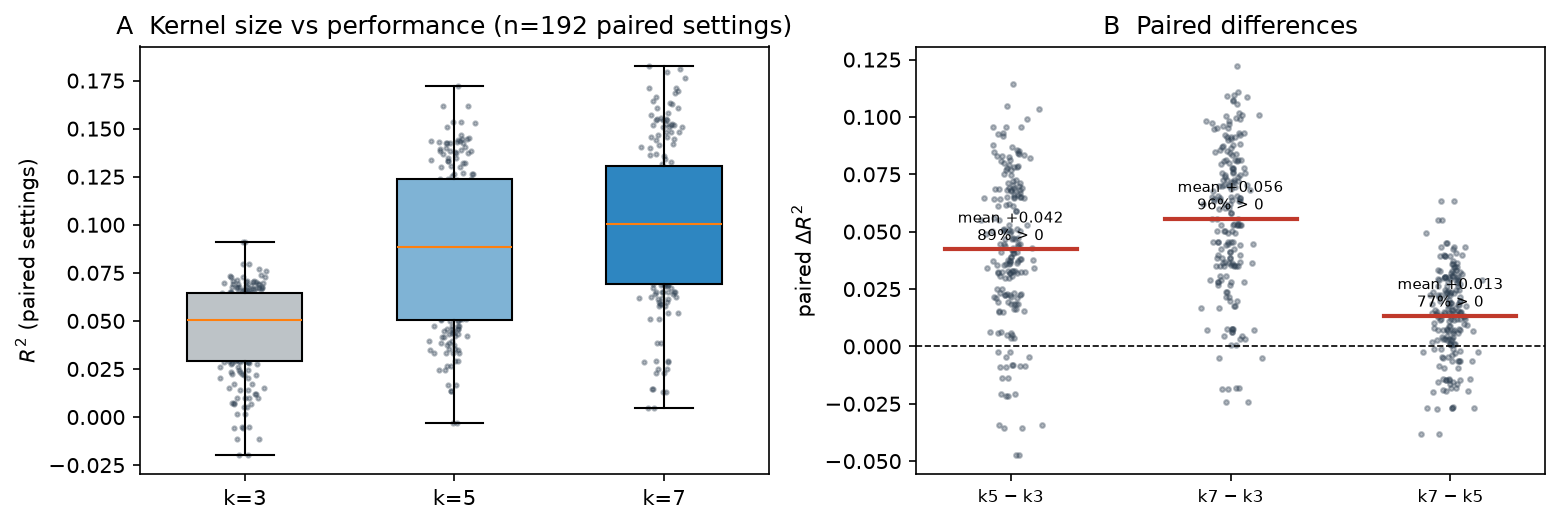

In [8]:
# --- Figure 3: kernel ablation ---
if experiments is not None and kernel_tbl is not None:
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6), dpi=150)

    ax = axes[0]
    data = [wide[c].values for c in ["k3", "k5", "k7"]]
    bp = ax.boxplot(data, tick_labels=["k=3", "k=5", "k=7"], widths=0.55, showfliers=False,
                    patch_artist=True)
    for patch, color in zip(bp["boxes"], ["#bdc3c7", "#7fb3d5", "#2e86c1"]):
        patch.set_facecolor(color)
    for i, d in enumerate(data):
        ax.scatter(np.full(len(d), i + 1) + np.random.default_rng(0).normal(0, 0.05, len(d)),
                   d, s=4, alpha=0.35, color="#2c3e50")
    ax.set_ylabel(r"$R^2$ (paired settings)")
    ax.set_title(f"A  Kernel size vs performance (n={len(wide)} paired settings)")

    ax = axes[1]
    for i, (a, b) in enumerate([("k5", "k3"), ("k7", "k3"), ("k7", "k5")]):
        d = (wide[a] - wide[b]).values
        ax.scatter(np.full(len(d), i) + np.random.default_rng(1).normal(0, 0.05, len(d)),
                   d, s=5, alpha=0.35, color="#2c3e50")
        ax.plot([i - 0.3, i + 0.3], [d.mean()] * 2, color="#c0392b", lw=2)
        ax.text(i, d.mean() + 0.004, f"mean {d.mean():+.3f}\n{(d > 0).mean():.0%} > 0",
                ha="center", fontsize=7)
    ax.axhline(0, color="k", lw=0.8, ls="--")
    ax.set_xticks(range(3))
    ax.set_xticklabels(["k5 − k3", "k7 − k3", "k7 − k5"], fontsize=8)
    ax.set_ylabel(r"paired $\Delta R^2$")
    ax.set_title("B  Paired differences")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "fig3_cnn_kernel_ablation.png", bbox_inches="tight")
    plt.show()


**观察**：在全部配对设置中，k = 5 与 k = 7 的 R² 高于 k = 3（配对差的均值为正，且大多数配对为正）。
**解释**：更大的序列卷积核提供更宽的局部感受野，可能更好地捕获本数据集中的局部序列上下文。
**限制**：这是模型层面（感受野）的解释，**不能**推断为"存在长度为 5 或 7 的生物学 motif"；
核大小与候选模式长度是两个不同概念（平台提取的候选模式长度需由归因窗口与聚类决定）。


### 4.3 Environmental incremental value：细胞环境是否提供额外预测信息？

读取已有的主效应表与逐样本配对 bootstrap 结果，比较四个表观遗传因子在序列基础上带来的**增量预测价值**（ΔR²）。

> 若结果整体较弱或方向不一致，本 Notebook **如实展示**，不为了"看起来有效"而挑选正结果。


In [9]:
main_effects = load_table("environment_main_effects.csv")
bootstrap = load_table("bootstrap_results.csv")

env_tbl = None
if main_effects is None:
    print("[SKIP] 4.3 requires environment_main_effects.csv")
else:
    stable = main_effects[main_effects["main_r2_delta"].abs() < 10.0]     # 隔离数值发散行
    per_model = stable.groupby(["environment", "model"])["main_r2_delta"].mean().reset_index()
    env_tbl = per_model.groupby("environment")["main_r2_delta"].agg(
        n_models="size", mean_dR2="mean", min="min", max="max").reset_index()
    env_tbl["models_positive"] = per_model.groupby("environment")["main_r2_delta"].apply(
        lambda s: int((s > 0).sum())).values
    if bootstrap is not None:
        b = bootstrap[bootstrap["metric"] == "R2"].copy()
        b["excl"] = b["excludes_zero"].astype(str).str.lower().map({"true": True, "false": False})
        b = b[b["status"] == "ok"]
        edge = b.groupby("added_environment").agg(n_edges=("excl", "size"),
                                                  edges_ci_excl0=("excl", "sum")).reset_index()
        env_tbl = env_tbl.merge(edge, left_on="environment", right_on="added_environment",
                                how="left")
    display(env_tbl.round(5))                          # noqa: F821


,environment,n_models,mean_dR2,min,max,models_positive,added_environment,n_edges,edges_ci_excl0
0,ctcf,7,-0.00095,-0.02807,0.00721,6,ctcf,634,53
1,dnase,7,-0.00202,-0.00769,0.00149,2,dnase,624,64
2,h3k4me3,7,-0.00594,-0.02456,0.00165,1,h3k4me3,641,68
3,rrbs,7,-0.00932,-0.05291,0.00096,1,rrbs,642,72


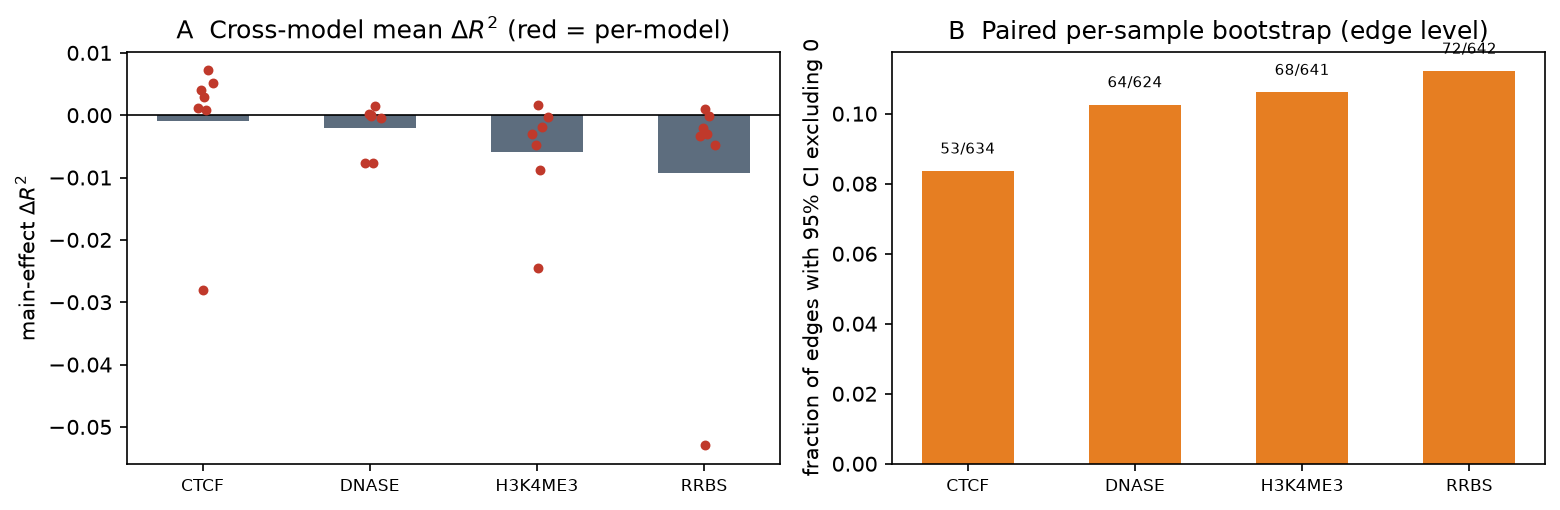

In [10]:
# --- Figure 4: environment incremental value ---
if env_tbl is not None and not env_tbl.empty:
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.5), dpi=150)
    factors = list(env_tbl["environment"])

    ax = axes[0]
    ax.bar(range(len(factors)), env_tbl["mean_dR2"], color="#5d6d7e", width=0.55)
    for i, f in enumerate(factors):
        vals = per_model[per_model.environment == f]["main_r2_delta"]
        ax.scatter(np.full(len(vals), i) + np.random.default_rng(0).normal(0, 0.05, len(vals)),
                   vals, s=14, color="#c0392b", zorder=3)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xticks(range(len(factors)))
    ax.set_xticklabels([f.upper() for f in factors], fontsize=8)
    ax.set_ylabel(r"main-effect $\Delta R^2$")
    ax.set_title(r"A  Cross-model mean $\Delta R^2$ (red = per-model)")

    ax = axes[1]
    frac = (env_tbl["edges_ci_excl0"] / env_tbl["n_edges"]).fillna(0.0)
    ax.bar(range(len(factors)), frac, color="#e67e22", width=0.55)
    for i, (n, k) in enumerate(zip(env_tbl["n_edges"].fillna(0), env_tbl["edges_ci_excl0"].fillna(0))):
        ax.text(i, frac.iloc[i] + 0.005, f"{int(k)}/{int(n)}", ha="center", fontsize=7)
    ax.set_xticks(range(len(factors)))
    ax.set_xticklabels([f.upper() for f in factors], fontsize=8)
    ax.set_ylabel("fraction of edges with 95% CI excluding 0")
    ax.set_title("B  Paired per-sample bootstrap (edge level)")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "fig4_environment_incremental.png", bbox_inches="tight")
    plt.show()


**观察**：四个表观遗传因子的跨模型平均 ΔR² 都是很小的量（|ΔR²| < 0.01），且方向并不一致；
绝大多数 lattice edge 的逐样本配对 bootstrap 置信区间跨过 0。

**解释**：在本数据集与当前编码方式下，**细胞环境特征提供的增量预测信息有限且依赖上下文**，
平台的析因方差分析在控制模型、细胞系与划分后也未检出显著主效应。

**限制与意义**：这一"弱结果"本身是平台价值的一部分——它说明平台不会把"看起来重要"当作"稳健成立"；
同时也提示环境信息可能与序列特征冗余、或受二值化编码限制，需要进一步验证（例如连续信号编码、更多细胞系）。


## Part 5 — Candidate Scientific Findings

以下条目由上面的真实结果**自动生成**（数值直接取自结果文件）。每条给出 Evidence / Interpretation / Limitation。


In [11]:
from IPython.display import Markdown, display as md_display   # noqa: F401

findings = []

if experiments is not None and not perf.empty:
    best = perf[perf.split_type == "single"].sort_values("R2_median", ascending=False).iloc[0]
    worst = perf[perf.split_type == "single"].sort_values("R2_median").iloc[0]
    findings.append(
        f"### Finding 1 — Models learn a weak but consistent editing-efficiency signal\n\n"
        f"Across **{len(experiments)} completed runs**, every model configuration achieved a positive "
        f"median held-out $R^2$; the best single-split configuration was **{best.model}** "
        f"(median $R^2$ = {best.R2_median:.3f}) and the lowest was {worst.model} "
        f"({worst.R2_median:.3f}).\n\n"
        f"**Evidence:** `tables/experiment_table.csv` (Figure 1).  "
        f"**Interpretation:** sequence + epigenomic inputs carry a learnable signal that justifies the "
        f"interpretation stage.  "
        f"**Limitation:** absolute performance is modest; prediction alone does not identify biological factors.")

if profile is not None and not profile.empty:
    region_means = pd.DataFrame({name: profile.loc[lo:hi].mean()
                                 for name, (lo, hi) in regions.items()})
    winners = region_means.idxmax(axis=1)                 # per model -> its highest region
    top_region = winners.value_counts().idxmax()
    n_models_top = int((winners == top_region).sum())
    pos18_rank = int((profile.mean(axis=1).rank(ascending=False)) .loc[18])
    findings.append(
        f"### Finding 2 — Cross-model attribution concentrates on the PAM-proximal region\n\n"
        f"**{n_models_top} of {len(winners)}** model classes gave their highest mean attribution to "
        f"**{top_region}**; position 18 ranked #{pos18_rank} in the cross-model mean profile.\n\n"
        f"**Evidence:** `tables/attribution_summary.csv` → Figure 2.  "
        f"**Interpretation:** models with different inductive biases consistently exploit local sequence "
        f"information next to the PAM.  "
        f"**Limitation:** attribution is model-derived evidence, not a causal effect; the direction of the "
        f"position-18 effect requires experimental validation.")

if kernel_tbl is not None:
    f53, f73 = kernel_tbl.loc["k5 - k3"], kernel_tbl.loc["k7 - k3"]
    findings.append(
        f"### Finding 3 — Larger CNN sequence kernels performed better in paired settings\n\n"
        f"Across **{int(kernel_tbl.loc['k3', 'n_settings'])} paired settings**, k=5 exceeded k=3 in "
        f"**{f53.positive_fraction:.0%}** of pairs (mean $\\Delta R^2$ = {f53['mean_R2']:+.3f}) and k=7 in "
        f"**{f73.positive_fraction:.0%}** (mean $\\Delta R^2$ = {f73['mean_R2']:+.3f}).\n\n"
        f"**Evidence:** `tables/experiment_table.csv` → Figure 3.  "
        f"**Interpretation:** a wider local receptive field may capture more predictive sequence context "
        f"in this dataset.  "
        f"**Limitation:** kernel size is a model hyper-parameter and must **not** be read as motif length.")

if env_tbl is not None and not env_tbl.empty:
    weakest = env_tbl.sort_values("mean_dR2").iloc[0]
    total_edges = int(env_tbl["n_edges"].fillna(0).sum())
    total_excl = int(env_tbl["edges_ci_excl0"].fillna(0).sum())
    findings.append(
        f"### Finding 4 — Cellular-environment features provided limited incremental predictive value\n\n"
        f"Cross-model mean $\\Delta R^2$ ranged from **{env_tbl['mean_dR2'].min():+.4f}** to "
        f"**{env_tbl['mean_dR2'].max():+.4f}**; only **{total_excl}/{total_edges}** lattice edges had a "
        f"paired per-sample bootstrap 95% CI excluding zero.\n\n"
        f"**Evidence:** `tables/environment_main_effects.csv` + `tables/bootstrap_results.csv` → Figure 4.  "
        f"**Interpretation:** in this dataset the epigenomic tracks add little information beyond sequence, "
        f"and part of the effect is context-dependent.  "
        f"**Limitation:** a weak incremental effect is not evidence of biological irrelevance; it may reflect "
        f"redundancy with sequence features or the binary encoding of the tracks.")

motifs = load_table("motif_candidates.csv")
if motifs is not None and not motifs.empty:
    n_sig = int((pd.to_numeric(motifs["FDR"], errors="coerce") < 0.05).sum())
    top = motifs.sort_values("support_count", ascending=False).iloc[0]
    findings.append(
        f"### Finding 5 — Candidate sequence patterns can be extracted from model attribution\n\n"
        f"**{len(motifs)}** candidate patterns were derived from CNN attribution, of which **{n_sig}** passed "
        f"BH-FDR < 0.05 in the enrichment test; the highest-support pattern was "
        f"`{top.human_pattern}` (IUPAC `{top.iupac}`, {int(top.support_count)} seqlets).\n\n"
        f"**Evidence:** `tables/motif_candidates.csv` (enrichment in `motif_enrichment.csv`).  "
        f"**Interpretation:** attribution can be aggregated into reproducible, position-annotated candidate "
        f"patterns that are testable hypotheses.  "
        f"**Limitation:** these are candidate patterns from model attribution; no wet-lab validation was "
        f"performed in this study.")

if findings:
    md_display(Markdown("\n\n---\n\n".join(findings)))
else:
    print("[SKIP] no findings could be generated (result files missing)")


### Finding 1 — Models learn a weak but consistent editing-efficiency signal

Across **1344 completed runs**, every model configuration achieved a positive median held-out $R^2$; the best single-split configuration was **xgboost** (median $R^2$ = 0.115) and the lowest was cnn(3|3) (0.035).

**Evidence:** `tables/experiment_table.csv` (Figure 1).  **Interpretation:** sequence + epigenomic inputs carry a learnable signal that justifies the interpretation stage.  **Limitation:** absolute performance is modest; prediction alone does not identify biological factors.

---

### Finding 2 — Cross-model attribution concentrates on the PAM-proximal region

**4 of 5** model classes gave their highest mean attribution to **PAM-proximal seed (17-20)**; position 18 ranked #1 in the cross-model mean profile.

**Evidence:** `tables/attribution_summary.csv` → Figure 2.  **Interpretation:** models with different inductive biases consistently exploit local sequence information next to the PAM.  **Limitation:** attribution is model-derived evidence, not a causal effect; the direction of the position-18 effect requires experimental validation.

---

### Finding 3 — Larger CNN sequence kernels performed better in paired settings

Across **192 paired settings**, k=5 exceeded k=3 in **89%** of pairs (mean $\Delta R^2$ = +0.042) and k=7 in **96%** (mean $\Delta R^2$ = +0.056).

**Evidence:** `tables/experiment_table.csv` → Figure 3.  **Interpretation:** a wider local receptive field may capture more predictive sequence context in this dataset.  **Limitation:** kernel size is a model hyper-parameter and must **not** be read as motif length.

---

### Finding 4 — Cellular-environment features provided limited incremental predictive value

Cross-model mean $\Delta R^2$ ranged from **-0.0093** to **-0.0009**; only **257/2541** lattice edges had a paired per-sample bootstrap 95% CI excluding zero.

**Evidence:** `tables/environment_main_effects.csv` + `tables/bootstrap_results.csv` → Figure 4.  **Interpretation:** in this dataset the epigenomic tracks add little information beyond sequence, and part of the effect is context-dependent.  **Limitation:** a weak incremental effect is not evidence of biological irrelevance; it may reflect redundancy with sequence features or the binary encoding of the tracks.

---

### Finding 5 — Candidate sequence patterns can be extracted from model attribution

**596** candidate patterns were derived from CNN attribution, of which **64** passed BH-FDR < 0.05 in the enrichment test; the highest-support pattern was `CTGG` (IUPAC `CTGG`, 1273 seqlets).

**Evidence:** `tables/motif_candidates.csv` (enrichment in `motif_enrichment.csv`).  **Interpretation:** attribution can be aggregated into reproducible, position-annotated candidate patterns that are testable hypotheses.  **Limitation:** these are candidate patterns from model attribution; no wet-lab validation was performed in this study.

## 结论与边界

**这个 Notebook 展示的是一条完整流程，而不是一个因果结论**：

```
DeepCRISPR 数据
   → 多模型受控训练（1 344 次，复用已有结果）
   → 预测能力确认（信号存在但较弱）
   → 多模型序列归因 → PAM 邻近区域与 position 18
   → CNN 多尺度感受野（k=5/7 > k=3）
   → 细胞环境的增量预测价值（本数据集中有限且依赖上下文）
   → 候选序列模式与可检验假设
```

**三条必须保留的边界**：

1. **attribution ≠ 因果**：模型依赖强度不等于生物学作用；位置/模式结论需要突变或编辑实验验证。
2. **kernel size ≠ motif length**：感受野是模型参数，候选模式长度由归因窗口与聚类决定。
3. **弱结果如实报告**：环境增量贡献在本数据集中很小，这是限制（limitation）而不是需要隐藏的结果。

**运行信息**：本 Notebook 只读取 `results/` 中已有结果文件，不训练模型、不重跑实验、不使用 GPU；
典型运行时间 < 1 分钟（attribution 汇总表约 42 MB，读取约 1 秒）。生成的图保存在 `notebooks/figures/`，
可直接用于 PPT。
